In [1]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid
from dolfinx.fem import functionspace, Function
import pickle
from dolfinx import mesh

In [56]:
filename = "./solutions/debug/test6_crippa_tr.pkl"
with open(filename, "rb") as f:
    data_Annika = pickle.load(f)

nx = data_Annika["geometry"]["nx"]
nz = data_Annika["geometry"]["nz"]
geom = Geometry()
geom.make_from_dict(data_Annika["geometry"])
domain = geom.make_domain(nx, nz, celltype=mesh.CellType.quadrilateral)
[P0, P1, P2, P3] = geom.corner_points
V = functionspace(domain, ("CG", 1))
Q = functionspace(domain, ("DG", 0))
W = functionspace(domain, ("CG", 1))
hw = Function(V)
phi = Function(Q)
T_i = Function(W)
T_w = Function(W)
p = Parameter(domain)

In [57]:
len(data_Annika["h_w"])

2

In [58]:
interval = data_Annika["saving_interval"]
t_obs = 1
time = data_Annika["times"][t_obs]
hw.x.array[:] = data_Annika["h_w"][t_obs]
phi.x.array[:] = data_Annika["phi"][t_obs]
T_i.x.array[:] = data_Annika["T_i"][t_obs]
T_w.x.array[:] = data_Annika["T_w"][t_obs]
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)
pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
porosity = eval_fct_on_grid(grid, phi, domain).reshape((nz, nx))
Ti = eval_fct_on_grid(grid, T_i, domain).reshape((nz, nx))
Tw = eval_fct_on_grid(grid, T_w, domain).reshape((nz, nx))
h_c = pressure_head * (pressure_head < 0)
def Se(h_c, alpha, N):
    return (1 + (- alpha * h_c)**N)**((1 - N) / N)
theta_tot = p.theta_r.value + (0.9*porosity - p.theta_r.value)*Se(h_c, p.alpha.value, p.N.value)
sat = Se(h_c, p.alpha.value, p.N.value)

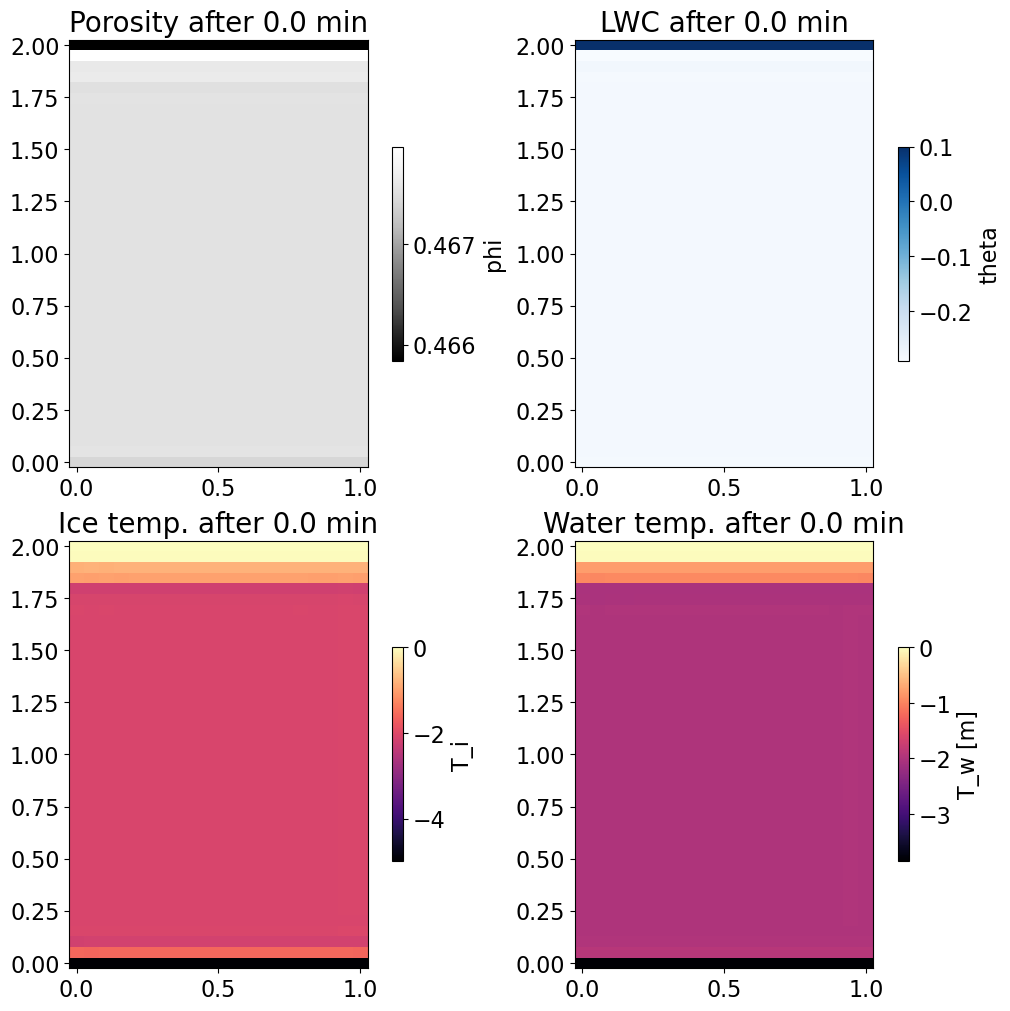

In [59]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(2,2, layout="constrained", figsize=(10,10))
pmsh1 = ax[0,0].pcolormesh(x_plot, z_plot, porosity, cmap="Greys_r")
ax[0,0].set_title(f"Porosity after {time/60:.1f} min", fontsize=20)
cbar1 = fig.colorbar(pmsh1, ax=ax[0,0], shrink=0.5)
cbar1.set_label("phi")
#ax[0,0].set_ylim(1.8,2)

pmsh2 = ax[0,1].pcolormesh(x_plot, z_plot, pressure_head, cmap="Blues")
ax[0,1].set_title(f"LWC after {time/60:.1f} min", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh2, ax=ax[0,1], shrink=0.5)
cbar2.set_label("theta")
#ax[0,1].set_ylim(1.8,2)

pmsh3 = ax[1,0].pcolormesh(x_plot, z_plot, Ti, cmap="magma")
ax[1,0].set_title(f"Ice temp. after {time/60:.1f} min", fontsize=20)
cbar1 = fig.colorbar(pmsh3, ax=ax[1,0], shrink=0.5)
cbar1.set_label("T_i")
#ax[1,0].set_ylim(1.8,2)

pmsh4 = ax[1,1].pcolormesh(x_plot, z_plot, Tw, cmap="magma")
ax[1,1].set_title(f"Water temp. after {time/60:.1f} min", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh4, ax=ax[1,1], shrink=0.5)
cbar2.set_label("T_w [m]")
#ax[1,1].set_ylim(1.8,2)

In [60]:
theta_tot

array([[0.02337516, 0.02337544, 0.02337545, 0.02337553, 0.0233755 ,
        0.02337552, 0.02337551, 0.02337551, 0.02337551, 0.02337551,
        0.02337551, 0.02337551, 0.02337551, 0.02337551, 0.02337551,
        0.02337551, 0.02337547, 0.02337565, 0.0233754 , 0.02337561],
       [0.02348707, 0.02348729, 0.02348736, 0.02348746, 0.02348743,
        0.02348744, 0.02348743, 0.02348743, 0.02348743, 0.02348743,
        0.02348743, 0.02348743, 0.02348743, 0.02348743, 0.02348743,
        0.02348743, 0.02348746, 0.02348739, 0.02348735, 0.02348734],
       [0.02354158, 0.02354157, 0.02354173, 0.02354178, 0.02354177,
        0.02354176, 0.02354177, 0.02354176, 0.02354176, 0.02354176,
        0.02354176, 0.02354177, 0.02354176, 0.02354177, 0.02354176,
        0.02354177, 0.0235418 , 0.02354166, 0.02354166, 0.02354193],
       [0.02351146, 0.02351154, 0.02351155, 0.0235116 , 0.02351157,
        0.02351157, 0.02351158, 0.02351158, 0.02351158, 0.02351158,
        0.02351158, 0.02351158, 0.02351158, 0

In [29]:
weights_sum = (p.c_pw.value/p.L_sol.value
                   + p.beta_sol.value/(p.rho_w.value*p.L_sol.value*p.r_i.value)
                   + p.beta_sol.value/(p.rho_w.value*p.L_sol.value*p.r_w.value))
a_i = (p.beta_sol.value/(p.rho_w.value*p.L_sol.value*p.r_i.value))/weights_sum
a_w = (p.beta_sol.value/(p.rho_w.value*p.L_sol.value*p.r_w.value))/weights_sum
a_m = (p.c_pw.value/p.L_sol.value)/weights_sum
print(a_i,a_w)

0.5336219898902349 0.3952755480668407


In [23]:
hwdg0 = Function(Q)
hwdg0.interpolate(hw)
Tidg0 = Function(Q)
Tidg0.interpolate(T_i)
Twdg0 = Function(Q)
Twdg0.interpolate(T_w)
p.r_i.value*p.W_SSA_numerical(p.S_e_numerical(hwdg0), phi)*p.D_i.value*(p.T_int_numerical(Tidg0, Twdg0)-Tidg0.x.array)

array([5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
       5.13328471e-08, 5.13328471e-08, 5.13328471e-08, 5.13328471e-08,
      

In [25]:
a_i = (p.K_i.value/p.r_i.value)/(p.K_i.value/p.r_i.value + p.K_w.value/p.r_w.value + p.rho_w.value*p.L_sol.value*p.R_m.value)
a_w = (p.K_w.value/p.r_w.value)/(p.K_i.value/p.r_i.value + p.K_w.value/p.r_w.value + p.rho_w.value*p.L_sol.value*p.R_m.value)
a_m = (p.rho_w.value*p.L_sol.value*p.R_m.value)/(p.K_i.value/p.r_i.value + p.K_w.value/p.r_w.value + p.rho_w.value*p.L_sol.value*p.R_m.value)
print(a_i, a_w)
Tint = a_i*-5+a_w*0
print(Tint)
print(a_i+a_w, a_m)

0.8081548483768577 0.14482218534717098
-4.0407742418842885
0.9529770337240286 0.047022966275971335


In [28]:
hwdg0 = Function(Q)
hwdg0.interpolate(hw)
w1 = p.W_SSA_numerical(p.S_e_numerical(hwdg0), phi)
def wssa_old(Se, phi):
    phi0 = 1 - p.rho_s.value/p.rho_i.value
    phi_arr = np.array(phi.x.array)
    reg_term = np.clip((Se - 1e-6), 0, None)
    wssa = (reg_term*p.SSA_0.value
            / (phi0*np.log(phi0))
            * phi_arr * np.log(phi_arr))
    return wssa
w2 = wssa_old(p.S_e_numerical(hwdg0), phi)
print(w1-w2)

[-111.30950288 -103.04878005 -111.30948715 -104.75992646 -103.0487414
 -111.30962645 -104.04256684 -104.75986973 -103.04899952 -111.30965196
 -103.90412306 -104.04249378 -104.76025766 -103.04904874 -111.3095956
 -103.62115068 -103.90403536 -104.04301708 -104.76033888 -103.04895075
 -111.30961768 -103.3704466  -103.62104894 -103.90470222 -104.0431336
 -104.76019755 -103.04899596 -111.30961496 -103.11068581 -103.37033118
 -103.62186361 -103.90485777 -104.04294883 -104.76026086 -103.04898593
 -111.3096294  -102.85279395 -103.11055738 -103.37129663 -103.6220604
 -103.90462728 -104.04303144 -104.76024544 -103.0490114  -111.30960137
 -102.59542729 -102.85265373 -103.11167562 -103.37153611 -103.62178299
 -103.90472969 -104.04300641 -104.76028266 -103.04896906 -111.30954726
 -102.34117625 -102.5952776  -102.85392626 -103.11195908 -103.3712112
 -103.62190556 -103.90469444 -104.04306065 -104.76024384 -103.04889509
 -102.09383508 -102.34102127 -102.59670551 -102.85425499 -103.11158653
 -103.37135

In [49]:
1 - p.rho_s.value/p.rho_i.value

np.float64(0.4678998911860718)